In [1]:
!pip -q install datasets transformers seqeval accelerate evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [2]:
# Loading and inspecting the SNIPS joint intent-slot dataset

from datasets import load_dataset

dataset = load_dataset("bkonkle/snips-joint-intent")

print(dataset)
print("\nTrain columns:", dataset["train"].column_names)
print("Test columns:", dataset["test"].column_names)

print("\nFirst training example:")
print(dataset["train"][0])

print("\nFirst test example:")
print(dataset["test"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/93.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13084 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 13084
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})

Train columns: ['input', 'intent', 'slots']
Test columns: ['input', 'intent', 'slots']

First training example:
{'input': 'listen to westbam alumb allergic on google music', 'intent': 'PlayMusic', 'slots': 'O O B-artist O B-album O B-service I-service'}

First test example:
{'input': 'add sabrina salerno to the grime instrumentals playlist', 'intent': 'AddToPlaylist', 'slots': 'O B-artist I-artist O O B-playlist I-playlist O'}


In [3]:
# Preparing labels and checking word-slot alignment

from datasets import DatasetDict

# Creating a validation split from training data
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

data = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
})

intent_labels = sorted(set(data["train"]["intent"]) | set(data["validation"]["intent"]) | set(data["test"]["intent"]))
intent2id = {label: i for i, label in enumerate(intent_labels)}
id2intent = {i: label for label, i in intent2id.items()}

slot_label_set = set()

for split in ["train", "validation", "test"]:
    for slot_string in data[split]["slots"]:
        slot_label_set.update(slot_string.split())

slot_labels = sorted(slot_label_set)
slot2id = {label: i for i, label in enumerate(slot_labels)}
id2slot = {i: label for label, i in slot2id.items()}

print("Dataset splits:")
print(data)

print("\nNumber of intent labels:", len(intent_labels))
print(intent_labels)

print("\nNumber of slot labels:", len(slot_labels))
print(slot_labels)

# Checking that number of words matches number of slot tags
def check_alignment(example):
    words = example["input"].split()
    slots = example["slots"].split()
    return len(words) == len(slots)

for split in ["train", "validation", "test"]:
    total = len(data[split])
    correct = sum(check_alignment(ex) for ex in data[split])
    print(f"{split}: {correct}/{total} examples have matching word-slot lengths")

# one processed example
ex = data["train"][0]
print("\nExample input:", ex["input"])
print("Words:", ex["input"].split())
print("Intent:", ex["intent"], "->", intent2id[ex["intent"]])
print("Slots:", ex["slots"].split())
print("Slot IDs:", [slot2id[s] for s in ex["slots"].split()])

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 11775
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})

Number of intent labels: 7
['AddToPlaylist', 'BookRestaurant', 'GetWeather', 'PlayMusic', 'RateBook', 'SearchCreativeWork', 'SearchScreeningEvent']

Number of slot labels: 72
['B-album', 'B-artist', 'B-best_rating', 'B-city', 'B-condition_description', 'B-condition_temperature', 'B-country', 'B-cuisine', 'B-current_location', 'B-entity_name', 'B-facility', 'B-genre', 'B-geographic_poi', 'B-location_name', 'B-movie_name', 'B-movie_type', 'B-music_item', 'B-object_location_type', 'B-object_name', 'B-object_part_of_series_type', 'B-object_select', 'B-object_type', 'B-party_size_description', 'B-party_size_number', 'B-playlist', 'B-playlist_owner', 'B-poi', 'B-

In [4]:
# Tokenisation and slot-label alignment for DistilBERT

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Filtering out the one example where word count != slot count
def is_aligned(example):
    return len(example["input"].split()) == len(example["slots"].split())

data = data.filter(is_aligned)

print("After filtering:")
print(data)

MAX_LENGTH = 64
IGNORE_INDEX = -100

def tokenize_and_align_labels(example):
    words = example["input"].split()
    slot_tags = example["slots"].split()

    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    word_ids = tokenized.word_ids()

    aligned_slot_ids = []
    previous_word_id = None

    for word_id in word_ids:
        if word_id is None:
            aligned_slot_ids.append(IGNORE_INDEX)
        elif word_id != previous_word_id:
            aligned_slot_ids.append(slot2id[slot_tags[word_id]])
        else:
            aligned_slot_ids.append(IGNORE_INDEX)
        previous_word_id = word_id

    tokenized["intent_label"] = intent2id[example["intent"]]
    tokenized["slot_labels"] = aligned_slot_ids
    tokenized["words"] = words
    tokenized["slot_tags"] = slot_tags

    return tokenized

encoded_data = data.map(tokenize_and_align_labels)

columns_to_keep = ["input_ids", "attention_mask", "intent_label", "slot_labels"]
encoded_data.set_format(type="torch", columns=columns_to_keep)

print("\nEncoded dataset:")
print(encoded_data)

sample = tokenize_and_align_labels(data["train"][0])
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

print("\nOriginal sentence:", data["train"][0]["input"])
print("Original slots:", data["train"][0]["slots"])
print("\nTokenised output:")
for tok, lab_id in zip(tokens, sample["slot_labels"]):
    label = "IGN" if lab_id == IGNORE_INDEX else id2slot[lab_id]
    print(f"{tok:15s} -> {label}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Filter:   0%|          | 0/11775 [00:00<?, ? examples/s]

...

After filtering:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 11774
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})


Map:   0%|          | 0/11774 [00:00<?, ? examples/s]

Map:   0%|          | 0/1309 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]


Encoded dataset:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 11774
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 700
    })
})

Original sentence: table for 6 at a brasserie
Original slots: O O B-party_size_number O O B-restaurant_type

Tokenised output:
[CLS]           -> IGN
table           -> O
for             -> O
6               -> B-party_size_number
at              -> O
a               -> O
brass           -> B-restaurant_type
##erie          -> IGN
[SEP]           -> IGN
[

In [5]:
# Defining a joint DistilBERT model for intent classification and slot filling

import torch
import torch.nn as nn
from transformers import AutoModel

class JointIntentSlotDistilBERT(nn.Module):
    def __init__(self, model_name, num_intents, num_slots, dropout_rate=0.2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(dropout_rate)

        self.intent_classifier = nn.Linear(hidden_size, num_intents)

        self.slot_classifier = nn.Linear(hidden_size, num_slots)

        self.intent_loss_fn = nn.CrossEntropyLoss()
        self.slot_loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    def forward(self, input_ids, attention_mask, intent_label=None, slot_labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = self.dropout(outputs.last_hidden_state)

        cls_output = sequence_output[:, 0, :]

        intent_logits = self.intent_classifier(cls_output)
        slot_logits = self.slot_classifier(sequence_output)

        loss = None

        if intent_label is not None and slot_labels is not None:
            intent_loss = self.intent_loss_fn(intent_logits, intent_label)

            # slot_logits: [batch, seq_len, num_slots]
            # slot_labels: [batch, seq_len]
            slot_loss = self.slot_loss_fn(
                slot_logits.view(-1, slot_logits.shape[-1]),
                slot_labels.view(-1)
            )

            loss = intent_loss + slot_loss

        return {
            "loss": loss,
            "intent_logits": intent_logits,
            "slot_logits": slot_logits
        }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = JointIntentSlotDistilBERT(
    model_name=MODEL_NAME,
    num_intents=len(intent_labels),
    num_slots=len(slot_labels)
).to(device)

print("Model created successfully.")
print("Number of intents:", len(intent_labels))
print("Number of slot labels:", len(slot_labels))

Using device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created successfully.
Number of intents: 7
Number of slot labels: 72


In [6]:
import datasets
import datasets.config

datasets.config.TORCHVISION_AVAILABLE = False

encoded_data.reset_format()

columns_to_keep = ["input_ids", "attention_mask", "intent_label", "slot_labels"]
encoded_data.set_format(type="torch", columns=columns_to_keep)

print("Torchvision disabled inside datasets.")
print("Dataset format reset successfully.")
print("Device:", device)

Torchvision disabled inside datasets.
Dataset format reset successfully.
Device: cuda


In [7]:
# Trainung the clean joint intent-slot model

from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import numpy as np
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 3e-5

train_loader = DataLoader(encoded_data["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(encoded_data["validation"], batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

def run_validation_loss(model, dataloader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            intent_label = batch["intent_label"].to(device)
            slot_labels = batch["slot_labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                intent_label=intent_label,
                slot_labels=slot_labels
            )

            total_loss += outputs["loss"].item()

    return total_loss / len(dataloader)


print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_label = batch["intent_label"].to(device)
        slot_labels = batch["slot_labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            intent_label=intent_label,
            slot_labels=slot_labels
        )

        loss = outputs["loss"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_train_loss += loss.item()
        progress_bar.set_postfix({"batch_loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = run_validation_loss(model, val_loader)

    print(f"\nEpoch {epoch + 1} completed")
    print(f"Average training loss: {avg_train_loss:.4f}")
    print(f"Average validation loss: {avg_val_loss:.4f}")
    print("-" * 50)

print("Training finished.")

Starting training...


Epoch 1/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 1 completed
Average training loss: 1.2057
Average validation loss: 0.2677
--------------------------------------------------


Epoch 2/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 2 completed
Average training loss: 0.1819
Average validation loss: 0.1978
--------------------------------------------------


Epoch 3/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 3 completed
Average training loss: 0.1001
Average validation loss: 0.1502
--------------------------------------------------
Training finished.


In [8]:
# Evaluation function for intent accuracy, slot F1, and semantic frame accuracy

from sklearn.metrics import accuracy_score
from seqeval.metrics import f1_score
from torch.utils.data import DataLoader
import pandas as pd

def evaluate_model(model, encoded_dataset, batch_size=32):
    model.eval()

    dataloader = DataLoader(encoded_dataset, batch_size=batch_size, shuffle=False)

    all_true_intents = []
    all_pred_intents = []

    all_true_slot_sequences = []
    all_pred_slot_sequences = []

    semantic_frame_correct = 0
    total_examples = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            true_intents = batch["intent_label"].to(device)
            true_slots = batch["slot_labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            intent_preds = torch.argmax(outputs["intent_logits"], dim=-1)
            slot_preds = torch.argmax(outputs["slot_logits"], dim=-1)

            for i in range(input_ids.size(0)):
                true_intent = true_intents[i].item()
                pred_intent = intent_preds[i].item()

                all_true_intents.append(true_intent)
                all_pred_intents.append(pred_intent)

                true_slot_seq = []
                pred_slot_seq = []

                for j in range(input_ids.size(1)):
                    true_label_id = true_slots[i][j].item()

                    if true_label_id != IGNORE_INDEX:
                        pred_label_id = slot_preds[i][j].item()

                        true_slot_seq.append(id2slot[true_label_id])
                        pred_slot_seq.append(id2slot[pred_label_id])

                all_true_slot_sequences.append(true_slot_seq)
                all_pred_slot_sequences.append(pred_slot_seq)

                if true_intent == pred_intent and true_slot_seq == pred_slot_seq:
                    semantic_frame_correct += 1

                total_examples += 1

    intent_accuracy = accuracy_score(all_true_intents, all_pred_intents)
    slot_f1 = f1_score(all_true_slot_sequences, all_pred_slot_sequences)
    semantic_frame_accuracy = semantic_frame_correct / total_examples

    return {
        "intent_accuracy": intent_accuracy,
        "slot_f1": slot_f1,
        "semantic_frame_accuracy": semantic_frame_accuracy
    }


clean_results = evaluate_model(model, encoded_data["test"])

print("Clean SNIPS Test Results")
print(f"Intent Accuracy: {clean_results['intent_accuracy']:.4f}")
print(f"Slot F1: {clean_results['slot_f1']:.4f}")
print(f"Semantic Frame Accuracy: {clean_results['semantic_frame_accuracy']:.4f}")

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

Clean SNIPS Test Results
Intent Accuracy: 0.9786
Slot F1: 0.9383
Semantic Frame Accuracy: 0.8571


In [9]:
# Creating noisy versions of the SNIPS test set

import copy
import string
import random
from datasets import Dataset

random.seed(SEED)

# Simple token-preserving misspelling function
def misspell_word(word):
    if len(word) <= 3:
        return word

    choice = random.choice(["delete", "swap", "repeat"])

    chars = list(word)

    if choice == "delete" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        del chars[idx]

    elif choice == "swap" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]

    elif choice == "repeat":
        idx = random.randint(1, len(chars) - 2)
        chars.insert(idx, chars[idx])

    return "".join(chars)


# Punctuation and casing noise
def punctuation_casing_noise(words):
    noisy_words = []

    for word in words:
        new_word = word

        # Random casing change
        r = random.random()
        if r < 0.30:
            new_word = new_word.upper()
        elif r < 0.60:
            new_word = new_word.lower()

        if random.random() < 0.15:
            new_word = new_word + random.choice([".", ",", "?", "!"])

        noisy_words.append(new_word)

    return noisy_words


# Token-preserving abbreviation/substitution noise
substitution_map = {
    "please": "pls",
    "restaurant": "resto",
    "restaurants": "restos",
    "tomorrow": "tmrw",
    "tonight": "tnite",
    "weather": "wthr",
    "music": "muzic",
    "playlist": "plylst",
    "movie": "mov",
    "movies": "movs",
    "book": "bk",
    "books": "bks",
    "rating": "rtng",
    "rate": "rt",
    "search": "srch",
    "play": "ply",
    "add": "ad",
    "for": "4",
    "to": "2",
    "you": "u",
    "your": "ur",
    "with": "w",
    "without": "w/o"
}

def substitution_noise(words):
    noisy_words = []

    for word in words:
        lower_word = word.lower().strip(string.punctuation)

        if lower_word in substitution_map and random.random() < 0.70:
            noisy_words.append(substitution_map[lower_word])
        else:
            noisy_words.append(word)

    return noisy_words


def misspelling_noise(words):
    noisy_words = []

    for word in words:
        if random.random() < 0.25:
            noisy_words.append(misspell_word(word))
        else:
            noisy_words.append(word)

    return noisy_words


def mixed_noise(words):
    noisy_words = misspelling_noise(words)
    noisy_words = punctuation_casing_noise(noisy_words)
    noisy_words = substitution_noise(noisy_words)
    return noisy_words


def make_noisy_dataset(original_dataset, noise_type):
    noisy_inputs = []
    intents = []
    slots = []

    for example in original_dataset:
        words = example["input"].split()

        if noise_type == "misspelling":
            noisy_words = misspelling_noise(words)
        elif noise_type == "punctuation_casing":
            noisy_words = punctuation_casing_noise(words)
        elif noise_type == "abbreviation_substitution":
            noisy_words = substitution_noise(words)
        elif noise_type == "mixed":
            noisy_words = mixed_noise(words)
        else:
            noisy_words = words

        noisy_inputs.append(" ".join(noisy_words))
        intents.append(example["intent"])
        slots.append(example["slots"])

    return Dataset.from_dict({
        "input": noisy_inputs,
        "intent": intents,
        "slots": slots
    })


noisy_test_sets = {
    "Misspelling": make_noisy_dataset(data["test"], "misspelling"),
    "Punctuation/Casing": make_noisy_dataset(data["test"], "punctuation_casing"),
    "Abbreviation/Substitution": make_noisy_dataset(data["test"], "abbreviation_substitution"),
    "Mixed Noise": make_noisy_dataset(data["test"], "mixed")
}

# examples
for name, noisy_ds in noisy_test_sets.items():
    print("\n" + "=" * 70)
    print(name)
    print("Original:", data["test"][0]["input"])
    print("Noisy   :", noisy_ds[0]["input"])
    print("Slots   :", noisy_ds[0]["slots"])


Misspelling
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : add sarbina saalerno to the girme instumentals playlist
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Punctuation/Casing
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : add SABRINA SALERNO TO the GRIME instrumentals playlist.
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Abbreviation/Substitution
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : ad sabrina salerno 2 the grime instrumentals plylst
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Mixed Noise
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : ad sabrina, SALERNO TO, the grmie INTRUMENTALS plylst
Slots   : O B-artist I-artist O O B-playlist I-playlist O


In [10]:
# Tokenising noisy test sets and evaluating robustness

def encode_dataset_for_evaluation(raw_dataset):
    encoded = raw_dataset.map(tokenize_and_align_labels)

    encoded.reset_format()
    encoded.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "intent_label", "slot_labels"]
    )

    return encoded


all_results = []

all_results.append({
    "Test condition": "Clean",
    "Intent Accuracy": clean_results["intent_accuracy"],
    "Slot F1": clean_results["slot_f1"],
    "Semantic Frame Accuracy": clean_results["semantic_frame_accuracy"]
})

# Evaluating each noisy test set
for condition_name, raw_noisy_dataset in noisy_test_sets.items():
    print("\n" + "=" * 70)
    print("Evaluating:", condition_name)

    encoded_noisy_dataset = encode_dataset_for_evaluation(raw_noisy_dataset)
    results = evaluate_model(model, encoded_noisy_dataset)

    all_results.append({
        "Test condition": condition_name,
        "Intent Accuracy": results["intent_accuracy"],
        "Slot F1": results["slot_f1"],
        "Semantic Frame Accuracy": results["semantic_frame_accuracy"]
    })

# Converting to DataFrame
results_df = pd.DataFrame(all_results)

# Calculating robustness drops compared with clean performance
clean_intent = clean_results["intent_accuracy"]
clean_slot_f1 = clean_results["slot_f1"]
clean_frame = clean_results["semantic_frame_accuracy"]

results_df["Intent Drop"] = clean_intent - results_df["Intent Accuracy"]
results_df["Slot F1 Drop"] = clean_slot_f1 - results_df["Slot F1"]
results_df["Semantic Frame Drop"] = clean_frame - results_df["Semantic Frame Accuracy"]

percentage_df = results_df.copy()

metric_columns = [
    "Intent Accuracy",
    "Slot F1",
    "Semantic Frame Accuracy",
    "Intent Drop",
    "Slot F1 Drop",
    "Semantic Frame Drop"
]

for col in metric_columns:
    percentage_df[col] = (percentage_df[col] * 100).round(2)

print("\nFinal Results Table:")
display(percentage_df)


Evaluating: Misspelling


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]


Evaluating: Punctuation/Casing


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

...


Evaluating: Mixed Noise


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]


Final Results Table:


,Test condition,Intent Accuracy,Slot F1,Semantic Frame Accuracy,Intent Drop,Slot F1 Drop,Semantic Frame Drop
0,Clean,97.86,93.83,85.71,0.00,0.00,0.00
1,Misspelling,95.43,78.57,55.43,2.43,15.27,30.29
2,Punctuation/Casing,97.86,89.32,69.86,0.00,4.52,15.86
3,Abbreviation/Substitution,94.14,77.91,51.00,3.71,15.92,34.71
4,Mixed Noise,90.14,62.76,26.29,7.71,31.07,59.43


Saved results table as snips_noise_robustness_results.csv


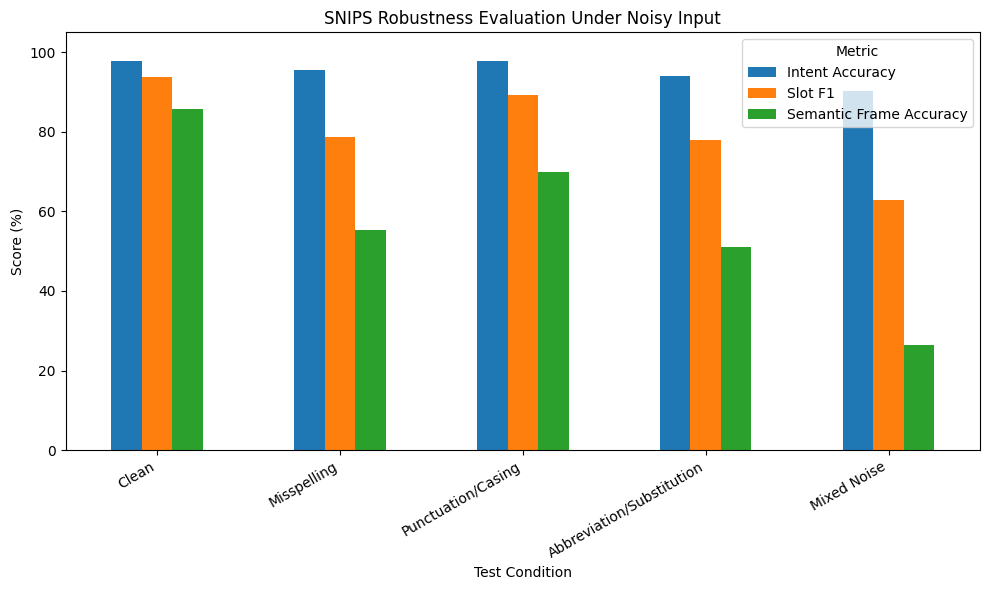

Saved graph as snips_noise_robustness_plot.png


In [11]:
# Saving results table and creating graph

import matplotlib.pyplot as plt

percentage_df.to_csv("snips_noise_robustness_results.csv", index=False)

print("Saved results table as snips_noise_robustness_results.csv")

plot_df = percentage_df[[
    "Test condition",
    "Intent Accuracy",
    "Slot F1",
    "Semantic Frame Accuracy"
]]

ax = plot_df.set_index("Test condition").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SNIPS Robustness Evaluation Under Noisy Input")
plt.xlabel("Test Condition")
plt.ylabel("Score (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig("snips_noise_robustness_plot.png", dpi=300)
plt.show()

print("Saved graph as snips_noise_robustness_plot.png")

# 2.3HD: Noise-Aware Augmentation Method

This section extends the 2.2D baseline experiment. In 2.2D, the clean-trained DistilBERT joint intent-slot model performed well on clean SNIPS data but degraded under noisy input, especially for slot F1 and semantic frame accuracy.

For the HD task, I implement a noise-aware data augmentation method. The baseline is the clean-trained DistilBERT model from 2.2D. The proposed method trains a second DistilBERT joint intent-slot model using clean SNIPS training data plus controlled noisy augmented examples.

Both models are evaluated on the same clean and noisy SNIPS test sets using intent accuracy, slot F1, semantic frame accuracy, and robustness drop.

In [12]:
# Saving HD baseline results

hd_baseline_df = percentage_df.copy()
hd_baseline_df.to_csv("2_3HD_baseline_clean_trained_results.csv", index=False)

print("Saved HD baseline results as 2_3HD_baseline_clean_trained_results.csv")
display(hd_baseline_df)

Saved HD baseline results as 2_3HD_baseline_clean_trained_results.csv


,Test condition,Intent Accuracy,Slot F1,Semantic Frame Accuracy,Intent Drop,Slot F1 Drop,Semantic Frame Drop
0,Clean,97.86,93.83,85.71,0.00,0.00,0.00
1,Misspelling,95.43,78.57,55.43,2.43,15.27,30.29
2,Punctuation/Casing,97.86,89.32,69.86,0.00,4.52,15.86
3,Abbreviation/Substitution,94.14,77.91,51.00,3.71,15.92,34.71
4,Mixed Noise,90.14,62.76,26.29,7.71,31.07,59.43


## HD Baseline Results

The clean-trained DistilBERT joint intent-slot model was re-run as the baseline for the HD experiment. It performed strongly on the clean SNIPS test set, but performance dropped substantially under noisy input. The largest degradation occurred under mixed noise, where slot F1 dropped by 31.07 percentage points and semantic frame accuracy dropped by 59.43 percentage points.

In [13]:
# Creating noise-augmented SNIPS training data

import random
import string
from datasets import Dataset, DatasetDict

random.seed(SEED)

# Noise functions

def misspell_word(word):
    if len(word) <= 3:
        return word

    choice = random.choice(["delete", "swap", "repeat"])
    chars = list(word)

    if choice == "delete" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        del chars[idx]

    elif choice == "swap" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]

    elif choice == "repeat":
        idx = random.randint(1, len(chars) - 2)
        chars.insert(idx, chars[idx])

    return "".join(chars)


def misspelling_noise(words):
    noisy_words = []

    for word in words:
        if random.random() < 0.25:
            noisy_words.append(misspell_word(word))
        else:
            noisy_words.append(word)

    return noisy_words


def punctuation_casing_noise(words):
    noisy_words = []

    for word in words:
        new_word = word

        r = random.random()
        if r < 0.30:
            new_word = new_word.upper()
        elif r < 0.60:
            new_word = new_word.lower()

        if random.random() < 0.15:
            new_word = new_word + random.choice([".", ",", "?", "!"])

        noisy_words.append(new_word)

    return noisy_words


substitution_map = {
    "please": "pls",
    "restaurant": "resto",
    "restaurants": "restos",
    "tomorrow": "tmrw",
    "tonight": "tnite",
    "weather": "wthr",
    "music": "muzic",
    "playlist": "plylst",
    "movie": "mov",
    "movies": "movs",
    "book": "bk",
    "books": "bks",
    "rating": "rtng",
    "rate": "rt",
    "search": "srch",
    "play": "ply",
    "add": "ad",
    "for": "4",
    "to": "2",
    "you": "u",
    "your": "ur",
    "with": "w",
    "without": "w/o"
}


def substitution_noise(words):
    noisy_words = []

    for word in words:
        lower_word = word.lower().strip(string.punctuation)

        if lower_word in substitution_map and random.random() < 0.70:
            noisy_words.append(substitution_map[lower_word])
        else:
            noisy_words.append(word)

    return noisy_words


def mixed_noise(words):
    noisy_words = misspelling_noise(words)
    noisy_words = punctuation_casing_noise(noisy_words)
    noisy_words = substitution_noise(noisy_words)
    return noisy_words


def apply_random_training_noise(words):
    noise_type = random.choice([
        "misspelling",
        "punctuation_casing",
        "abbreviation_substitution",
        "mixed"
    ])

    if noise_type == "misspelling":
        return misspelling_noise(words), noise_type

    elif noise_type == "punctuation_casing":
        return punctuation_casing_noise(words), noise_type

    elif noise_type == "abbreviation_substitution":
        return substitution_noise(words), noise_type

    else:
        return mixed_noise(words), noise_type


# Building augmented training set

all_inputs = []
all_intents = []
all_slots = []
source_type = []

noise_counts = {
    "clean": 0,
    "misspelling": 0,
    "punctuation_casing": 0,
    "abbreviation_substitution": 0,
    "mixed": 0
}

for example in data["train"]:
    words = example["input"].split()
    slot_tags = example["slots"].split()

    if len(words) != len(slot_tags):
        continue

    all_inputs.append(example["input"])
    all_intents.append(example["intent"])
    all_slots.append(example["slots"])
    source_type.append("clean")
    noise_counts["clean"] += 1

    noisy_words, chosen_noise = apply_random_training_noise(words)

    all_inputs.append(" ".join(noisy_words))
    all_intents.append(example["intent"])
    all_slots.append(example["slots"])
    source_type.append(chosen_noise)
    noise_counts[chosen_noise] += 1


augmented_train_dataset = Dataset.from_dict({
    "input": all_inputs,
    "intent": all_intents,
    "slots": all_slots,
    "source_type": source_type
})

hd_data = DatasetDict({
    "train": augmented_train_dataset,
    "validation": data["validation"],
    "test": data["test"]
})

print("HD dataset created successfully.")
print(hd_data)

print("\nNoise distribution in HD training data:")
for key, value in noise_counts.items():
    print(f"{key}: {value}")

print("\nOriginal clean training size:", len(data["train"]))
print("Augmented HD training size:", len(hd_data["train"]))

print("\nExample clean training input:")
print(hd_data["train"][0]["input"])
print(hd_data["train"][0]["slots"])
print(hd_data["train"][0]["source_type"])

print("\nExample noisy augmented input:")
print(hd_data["train"][1]["input"])
print(hd_data["train"][1]["slots"])
print(hd_data["train"][1]["source_type"])

HD dataset created successfully.
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots', 'source_type'],
        num_rows: 23548
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})

Noise distribution in HD training data:
clean: 11774
misspelling: 2979
punctuation_casing: 2932
abbreviation_substitution: 2918
mixed: 2945

Original clean training size: 11774
Augmented HD training size: 23548

Example clean training input:
table for 6 at a brasserie
O O B-party_size_number O O B-restaurant_type
clean

Example noisy augmented input:
tbale for 6 at a barsserie
O O B-party_size_number O O B-restaurant_type
misspelling


In [14]:
# Tokenising augmented HD training data

encoded_hd_data = hd_data.map(tokenize_and_align_labels)

# PyTorch format
encoded_hd_data.reset_format()
encoded_hd_data.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "intent_label", "slot_labels"]
)

print("Encoded HD dataset:")
print(encoded_hd_data)

# Checking one clean and one noisy example after tokenisation
sample_clean = tokenize_and_align_labels(hd_data["train"][0])
sample_noisy = tokenize_and_align_labels(hd_data["train"][1])

print("\nClean example:")
print(hd_data["train"][0]["input"])
print(hd_data["train"][0]["slots"])
print(hd_data["train"][0]["source_type"])

print("\nNoisy augmented example:")
print(hd_data["train"][1]["input"])
print(hd_data["train"][1]["slots"])
print(hd_data["train"][1]["source_type"])

Map:   0%|          | 0/23548 [00:00<?, ? examples/s]

Encoded HD dataset:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots', 'source_type', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 23548
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 700
    })
})

Clean example:
table for 6 at a brasserie
O O B-party_size_number O O B-restaurant_type
clean

Noisy augmented example:
tbale for 6 at a barsserie
O O B-party_size_number O O B-restaurant_type
misspelling


In [15]:
# Training proposed noise-augmented DistilBERT model

from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import numpy as np
import random
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


NUM_INTENTS = len(intent2id)
NUM_SLOTS = len(slot2id)

print("Number of intents:", NUM_INTENTS)
print("Number of slot labels:", NUM_SLOTS)

# Creating a fresh model for the proposed method
augmented_model = JointIntentSlotDistilBERT(
    model_name=MODEL_NAME,
    num_intents=NUM_INTENTS,
    num_slots=NUM_SLOTS
).to(device)

BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 3e-5

aug_train_loader = DataLoader(encoded_hd_data["train"], batch_size=BATCH_SIZE, shuffle=True)
aug_val_loader = DataLoader(encoded_hd_data["validation"], batch_size=BATCH_SIZE, shuffle=False)

aug_optimizer = AdamW(augmented_model.parameters(), lr=LEARNING_RATE)

print("Starting training for proposed noise-augmented model...")
print("Training examples:", len(encoded_hd_data["train"]))
print("Validation examples:", len(encoded_hd_data["validation"]))
print("Device:", device)

for epoch in range(EPOCHS):
    augmented_model.train()
    total_train_loss = 0

    progress_bar = tqdm(aug_train_loader, desc=f"Augmented Model Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress_bar:
        aug_optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_label_batch = batch["intent_label"].to(device)
        slot_label_batch = batch["slot_labels"].to(device)

        outputs = augmented_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            intent_label=intent_label_batch,
            slot_labels=slot_label_batch
        )

        loss = outputs["loss"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(augmented_model.parameters(), max_norm=1.0)

        aug_optimizer.step()

        total_train_loss += loss.item()
        progress_bar.set_postfix({"batch_loss": loss.item()})

    avg_train_loss = total_train_loss / len(aug_train_loader)
    avg_val_loss = run_validation_loss(augmented_model, aug_val_loader)

    print(f"\nEpoch {epoch + 1} completed")
    print(f"Average augmented training loss: {avg_train_loss:.4f}")
    print(f"Average validation loss: {avg_val_loss:.4f}")
    print("-" * 50)

print("Noise-augmented model training finished.")

Number of intents: 7
Number of slot labels: 72


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training for proposed noise-augmented model...
Training examples: 23548
Validation examples: 1309
Device: cuda


Augmented Model Epoch 1/3:   0%|          | 0/736 [00:00<?, ?it/s]


Epoch 1 completed
Average augmented training loss: 0.8288
Average validation loss: 0.1805
--------------------------------------------------


Augmented Model Epoch 2/3:   0%|          | 0/736 [00:00<?, ?it/s]


Epoch 2 completed
Average augmented training loss: 0.1286
Average validation loss: 0.1659
--------------------------------------------------


Augmented Model Epoch 3/3:   0%|          | 0/736 [00:00<?, ?it/s]


Epoch 3 completed
Average augmented training loss: 0.0563
Average validation loss: 0.1654
--------------------------------------------------
Noise-augmented model training finished.


In [16]:
# Evaluating proposed noise-augmented model on clean and noisy test sets

# Clean test evaluation
aug_clean_results = evaluate_model(augmented_model, encoded_hd_data["test"])

print("Noise-Augmented Model: Clean SNIPS Test Results")
print(f"Intent Accuracy: {aug_clean_results['intent_accuracy']:.4f}")
print(f"Slot F1: {aug_clean_results['slot_f1']:.4f}")
print(f"Semantic Frame Accuracy: {aug_clean_results['semantic_frame_accuracy']:.4f}")


# Evaluating on the same noisy test sets used for the baseline
augmented_results = {
    "Clean": aug_clean_results
}

for noise_name, noisy_dataset in noisy_test_sets.items():
    print("\n" + "=" * 70)
    print(f"Evaluating noise-augmented model on: {noise_name}")

    encoded_noisy_dataset = noisy_dataset.map(tokenize_and_align_labels)
    encoded_noisy_dataset.reset_format()
    encoded_noisy_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "intent_label", "slot_labels"]
    )

    result = evaluate_model(augmented_model, encoded_noisy_dataset)
    augmented_results[noise_name] = result

    print(f"Intent Accuracy: {result['intent_accuracy']:.4f}")
    print(f"Slot F1: {result['slot_f1']:.4f}")
    print(f"Semantic Frame Accuracy: {result['semantic_frame_accuracy']:.4f}")


# Converting augmented model results to percentage table
aug_rows = []

clean_aug_intent = augmented_results["Clean"]["intent_accuracy"] * 100
clean_aug_slot = augmented_results["Clean"]["slot_f1"] * 100
clean_aug_frame = augmented_results["Clean"]["semantic_frame_accuracy"] * 100

for condition, result in augmented_results.items():
    intent_acc = result["intent_accuracy"] * 100
    slot_f1 = result["slot_f1"] * 100
    frame_acc = result["semantic_frame_accuracy"] * 100

    aug_rows.append({
        "Test condition": condition,
        "Intent Accuracy": round(intent_acc, 2),
        "Slot F1": round(slot_f1, 2),
        "Semantic Frame Accuracy": round(frame_acc, 2),
        "Intent Drop": round(clean_aug_intent - intent_acc, 2),
        "Slot F1 Drop": round(clean_aug_slot - slot_f1, 2),
        "Semantic Frame Drop": round(clean_aug_frame - frame_acc, 2)
    })

hd_augmented_df = pd.DataFrame(aug_rows)

print("\nNoise-Augmented Model Results Table:")
display(hd_augmented_df)

hd_augmented_df.to_csv("2_3HD_augmented_model_results.csv", index=False)
print("Saved augmented model results as 2_3HD_augmented_model_results.csv")

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

Noise-Augmented Model: Clean SNIPS Test Results
Intent Accuracy: 0.9757
Slot F1: 0.9444
Semantic Frame Accuracy: 0.8700

Evaluating noise-augmented model on: Misspelling


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

Intent Accuracy: 0.9671
Slot F1: 0.8914
Semantic Frame Accuracy: 0.7514

Evaluating noise-augmented model on: Punctuation/Casing


...

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

Intent Accuracy: 0.9700
Slot F1: 0.8877
Semantic Frame Accuracy: 0.7529

Noise-Augmented Model Results Table:


,Test condition,Intent Accuracy,Slot F1,Semantic Frame Accuracy,Intent Drop,Slot F1 Drop,Semantic Frame Drop
0,Clean,97.57,94.44,87.00,0.00,0.00,0.00
1,Misspelling,96.71,89.14,75.14,0.86,5.30,11.86
2,Punctuation/Casing,97.57,93.86,86.00,0.00,0.58,1.00
3,Abbreviation/Substitution,97.71,93.63,84.86,-0.14,0.81,2.14
4,Mixed Noise,97.00,88.77,75.29,0.57,5.67,11.71


Saved augmented model results as 2_3HD_augmented_model_results.csv


In [17]:
# Comparing baseline clean-trained model with noise-augmented model

comparison_rows = []

for condition in hd_baseline_df["Test condition"]:
    baseline_row = hd_baseline_df[hd_baseline_df["Test condition"] == condition].iloc[0]
    augmented_row = hd_augmented_df[hd_augmented_df["Test condition"] == condition].iloc[0]

    comparison_rows.append({
        "Test condition": condition,

        "Baseline Intent Accuracy": baseline_row["Intent Accuracy"],
        "Augmented Intent Accuracy": augmented_row["Intent Accuracy"],
        "Intent Improvement": round(augmented_row["Intent Accuracy"] - baseline_row["Intent Accuracy"], 2),

        "Baseline Slot F1": baseline_row["Slot F1"],
        "Augmented Slot F1": augmented_row["Slot F1"],
        "Slot F1 Improvement": round(augmented_row["Slot F1"] - baseline_row["Slot F1"], 2),

        "Baseline Semantic Frame Accuracy": baseline_row["Semantic Frame Accuracy"],
        "Augmented Semantic Frame Accuracy": augmented_row["Semantic Frame Accuracy"],
        "Semantic Frame Improvement": round(
            augmented_row["Semantic Frame Accuracy"] - baseline_row["Semantic Frame Accuracy"], 2
        )
    })

hd_comparison_df = pd.DataFrame(comparison_rows)

print("HD Baseline vs Noise-Augmented Model Comparison:")
display(hd_comparison_df)

hd_comparison_df.to_csv("2_3HD_baseline_vs_augmented_comparison.csv", index=False)
print("Saved comparison table as 2_3HD_baseline_vs_augmented_comparison.csv")

HD Baseline vs Noise-Augmented Model Comparison:


,Test condition,Baseline Intent Accuracy,Augmented Intent Accuracy,Intent Improvement,Baseline Slot F1,Augmented Slot F1,Slot F1 Improvement,Baseline Semantic Frame Accuracy,Augmented Semantic Frame Accuracy,Semantic Frame Improvement
0,Clean,97.86,97.57,-0.29,93.83,94.44,0.61,85.71,87.00,1.29
1,Misspelling,95.43,96.71,1.28,78.57,89.14,10.57,55.43,75.14,19.71
2,Punctuation/Casing,97.86,97.57,-0.29,89.32,93.86,4.54,69.86,86.00,16.14
3,Abbreviation/Substitution,94.14,97.71,3.57,77.91,93.63,15.72,51.00,84.86,33.86
4,Mixed Noise,90.14,97.00,6.86,62.76,88.77,26.01,26.29,75.29,49.00


Saved comparison table as 2_3HD_baseline_vs_augmented_comparison.csv


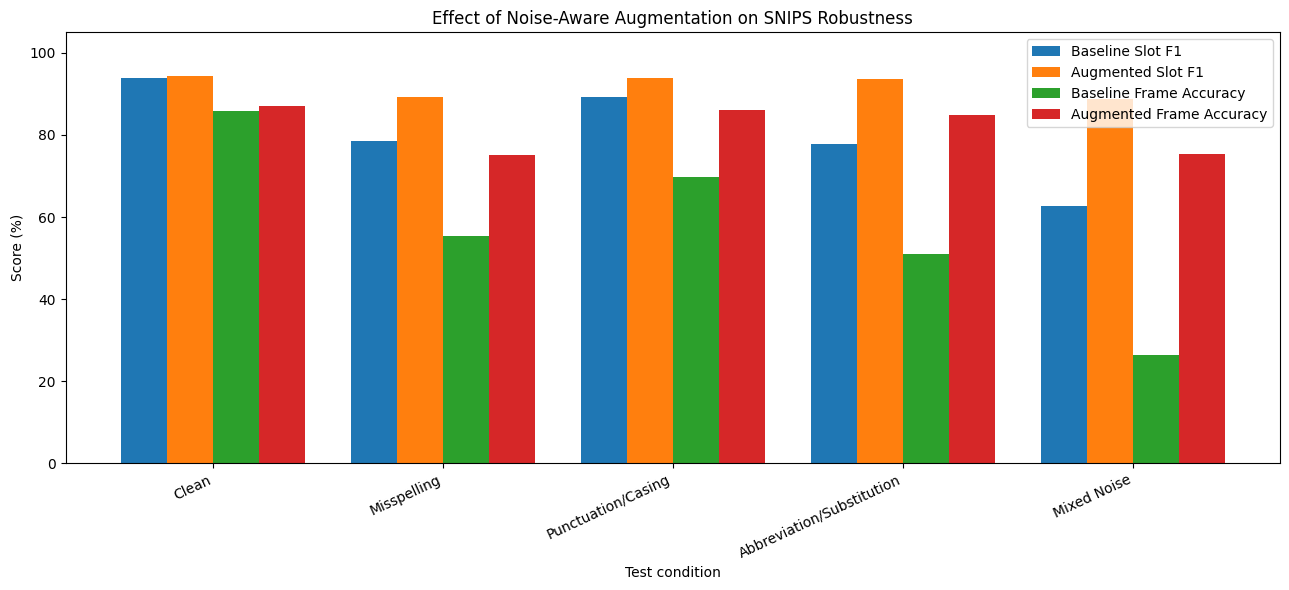

Saved plot as 2_3HD_baseline_vs_augmented_plot.png


In [18]:
# Plotting baseline vs augmented model comparison

import matplotlib.pyplot as plt
import numpy as np

conditions = hd_comparison_df["Test condition"].tolist()

baseline_slot = hd_comparison_df["Baseline Slot F1"].tolist()
augmented_slot = hd_comparison_df["Augmented Slot F1"].tolist()

baseline_frame = hd_comparison_df["Baseline Semantic Frame Accuracy"].tolist()
augmented_frame = hd_comparison_df["Augmented Semantic Frame Accuracy"].tolist()

x = np.arange(len(conditions))
width = 0.20

plt.figure(figsize=(13, 6))

plt.bar(x - 1.5 * width, baseline_slot, width, label="Baseline Slot F1")
plt.bar(x - 0.5 * width, augmented_slot, width, label="Augmented Slot F1")
plt.bar(x + 0.5 * width, baseline_frame, width, label="Baseline Frame Accuracy")
plt.bar(x + 1.5 * width, augmented_frame, width, label="Augmented Frame Accuracy")

plt.xticks(x, conditions, rotation=25, ha="right")
plt.ylabel("Score (%)")
plt.xlabel("Test condition")
plt.title("Effect of Noise-Aware Augmentation on SNIPS Robustness")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()

plt.savefig("2_3HD_baseline_vs_augmented_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot as 2_3HD_baseline_vs_augmented_plot.png")

In [19]:
# Error Analysis: Mixed Noise examples where the augmented model succeeds or still fails

import pandas as pd
import torch

required_vars = [
    "model", "augmented_model", "noisy_test_sets", "data",
    "tokenizer", "device", "id2intent", "id2slot",
    "intent2id", "slot2id", "IGNORE_INDEX", "MAX_LENGTH"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise RuntimeError(
        "These required variables are missing from memory: "
        + ", ".join(missing_vars)
        + "\nYou need to rerun the notebook before running error analysis."
    )

baseline_model = model
proposed_model = augmented_model

mixed_dataset = noisy_test_sets["Mixed Noise"]

def predict_single_example(model_to_use, example):
    model_to_use.eval()

    words = example["input"].split()
    gold_slot_tags = example["slots"].split()

    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    word_ids = tokenized.word_ids(batch_index=0)

    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model_to_use(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    pred_intent_id = torch.argmax(outputs["intent_logits"], dim=-1).item()
    pred_intent = id2intent[pred_intent_id]

    pred_slot_ids = torch.argmax(outputs["slot_logits"], dim=-1).squeeze(0).cpu().tolist()

    pred_slot_tags = []
    previous_word_id = None

    for token_index, word_id in enumerate(word_ids):
        if word_id is None:
            continue

        if word_id != previous_word_id:
            pred_slot_tags.append(id2slot[pred_slot_ids[token_index]])

        previous_word_id = word_id

    return pred_intent, pred_slot_tags


error_rows = []

for i in range(len(mixed_dataset)):
    original_example = data["test"][i]
    noisy_example = mixed_dataset[i]

    gold_intent = noisy_example["intent"]
    gold_slots = noisy_example["slots"].split()

    baseline_intent, baseline_slots = predict_single_example(baseline_model, noisy_example)
    augmented_intent, augmented_slots = predict_single_example(proposed_model, noisy_example)

    baseline_intent_correct = baseline_intent == gold_intent
    augmented_intent_correct = augmented_intent == gold_intent

    baseline_slots_correct = baseline_slots == gold_slots
    augmented_slots_correct = augmented_slots == gold_slots

    baseline_frame_correct = baseline_intent_correct and baseline_slots_correct
    augmented_frame_correct = augmented_intent_correct and augmented_slots_correct

    if (not baseline_frame_correct) and augmented_frame_correct:
        case_type = "recovered_by_augmented_model"
    elif (not augmented_frame_correct):
        case_type = "still_failed_by_augmented_model"
    else:
        case_type = "correct_by_both_models"

    error_rows.append({
        "index": i,
        "case_type": case_type,
        "original_input": original_example["input"],
        "mixed_noisy_input": noisy_example["input"],
        "gold_intent": gold_intent,
        "baseline_intent": baseline_intent,
        "augmented_intent": augmented_intent,
        "gold_slots": " ".join(gold_slots),
        "baseline_slots": " ".join(baseline_slots),
        "augmented_slots": " ".join(augmented_slots),
        "baseline_intent_correct": baseline_intent_correct,
        "augmented_intent_correct": augmented_intent_correct,
        "baseline_slots_correct": baseline_slots_correct,
        "augmented_slots_correct": augmented_slots_correct,
        "baseline_frame_correct": baseline_frame_correct,
        "augmented_frame_correct": augmented_frame_correct
    })

error_analysis_df = pd.DataFrame(error_rows)

print("Mixed Noise Error Analysis Summary")
print(error_analysis_df["case_type"].value_counts())

print("\nRecovered examples: baseline failed, augmented model succeeded")
recovered_examples = error_analysis_df[
    error_analysis_df["case_type"] == "recovered_by_augmented_model"
].head(5)
display(recovered_examples)

print("\nRemaining failure examples: augmented model still failed")
remaining_failures = error_analysis_df[
    error_analysis_df["case_type"] == "still_failed_by_augmented_model"
].head(5)
display(remaining_failures)

error_analysis_df.to_csv("2_3HD_error_analysis_mixed_noise.csv", index=False)
print("\nSaved full error analysis as 2_3HD_error_analysis_mixed_noise.csv")

Mixed Noise Error Analysis Summary
case_type
recovered_by_augmented_model       355
still_failed_by_augmented_model    173
correct_by_both_models             172
Name: count, dtype: int64

Recovered examples: baseline failed, augmented model succeeded


,index,case_type,original_input,mixed_noisy_input,gold_intent,baseline_intent,augmented_intent,gold_slots,baseline_slots,augmented_slots,baseline_intent_correct,augmented_intent_correct,baseline_slots_correct,augmented_slots_correct,baseline_frame_correct,augmented_frame_correct
0,0,recovered_by_augmented_model,add sabrina salerno to the grime instrumentals...,"ad sabrina, SALERNO TO, the grmie INTRUMENTALS...",AddToPlaylist,AddToPlaylist,AddToPlaylist,O B-artist I-artist O O B-playlist I-playlist O,O B-entity_name I-entity_name O B-object_name ...,O B-artist I-artist O O B-playlist I-playlist O,True,True,False,True,False,True
3,3,recovered_by_augmented_model,will it snow in mt on june 13 2038,"will, it, SNOW in mt on. JUE 13 2038,",GetWeather,GetWeather,GetWeather,O O B-condition_description O B-state O B-time...,O O B-condition_description O B-state O I-time...,O O B-condition_description O B-state O B-time...,True,True,False,True,False,True
5,5,recovered_by_augmented_model,can you let me know what animated movies are p...,can? u LET ME know. WHAT animated movs are ply...,SearchScreeningEvent,SearchScreeningEvent,SearchScreeningEvent,O O O O O O B-movie_type I-movie_type O O B-sp...,O O O O O O B-movie_type I-movie_name O O B-sp...,O O O O O O B-movie_type I-movie_type O O B-sp...,True,True,False,True,False,True
7,7,recovered_by_augmented_model,what s the weather here on 2/7/2021,WHAT S. the wthr heer on 2/7/2021,GetWeather,GetWeather,GetWeather,O O O O B-current_location O B-timeRange,O O O I-object_name O O B-timeRange,O O O O B-current_location O B-timeRange,True,True,False,True,False,True
8,8,recovered_by_augmented_model,find worldly goods starting now at a movie house,find worlddly GOODS starting now! at a mov HOUSE,SearchScreeningEvent,SearchScreeningEvent,SearchScreeningEvent,O B-movie_name I-movie_name O B-timeRange O O ...,O B-movie_name I-movie_name O B-timeRange O O ...,O B-movie_name I-movie_name O B-timeRange O O ...,True,True,False,True,False,True



Remaining failure examples: augmented model still failed


,index,case_type,original_input,mixed_noisy_input,gold_intent,baseline_intent,augmented_intent,gold_slots,baseline_slots,augmented_slots,baseline_intent_correct,augmented_intent_correct,baseline_slots_correct,augmented_slots_correct,baseline_frame_correct,augmented_frame_correct
1,1,still_failed_by_augmented_model,i want to bring four people to a place that s ...,i WAT to BRING FOUR people TO a place THAT s c...,BookRestaurant,BookRestaurant,BookRestaurant,O O O O B-party_size_number O O O O O O B-spat...,O O O O B-party_size_number O O O O O O B-spat...,O O O O B-party_size_number O O O O O O B-spat...,True,True,False,False,False,False
2,2,still_failed_by_augmented_model,put lindsey cardinale into my hillary clinton ...,PUT lindsey cardinale INTO! MY hillary clinton...,AddToPlaylist,AddToPlaylist,AddToPlaylist,O B-artist I-artist O B-playlist_owner B-playl...,O B-artist I-artist O I-playlist B-playlist I-...,O B-artist I-artist O B-playlist_owner B-playl...,True,True,False,False,False,False
4,4,still_failed_by_augmented_model,play signe anderson chant music that is newest,ply signe aderson chant muzic THTA is newest,PlayMusic,AddToPlaylist,PlayMusic,O B-artist I-artist B-music_item O O O B-sort,O B-artist I-artist B-music_item I-album I-alb...,O B-artist I-artist B-music_item O B-track I-t...,False,True,False,False,False,False
6,6,still_failed_by_augmented_model,can you get me reservations for a highly rated...,"can u GET me reservatinos. 4 A, HIGHLY rated r...",BookRestaurant,BookRestaurant,BookRestaurant,O O O O O O O B-sort I-sort B-restaurant_type ...,O O O O B-object_name I-object_name O B-sort I...,O O O O O O O B-sort I-sort B-restaurant_type ...,True,True,False,False,False,False
12,12,still_failed_by_augmented_model,find on dress parade,find on dress parade?,SearchScreeningEvent,SearchCreativeWork,SearchCreativeWork,O B-movie_name I-movie_name I-movie_name,O B-object_name I-object_name I-object_name,O B-object_name I-object_name I-object_name,False,False,False,False,False,False



Saved full error analysis as 2_3HD_error_analysis_mixed_noise.csv
